In [7]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import (
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
    RandomForestClassifier,
)
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    log_loss,
    roc_auc_score,
    RocCurveDisplay,
)
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_val_score,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.tree import plot_tree


# Welche Persongruppe hatte die besten Überlebenschancen auf der Titanic?

In [8]:
df = pd.read_csv("train.csv", delimiter=";")

## Feature engineering

In [9]:
df = df.drop(['Name', 'PassengerId', 'Ticket', 'Cabin', 'Unnamed: 0', 'Embarked'], axis=1)
df = df.drop(columns=[c for c in df.columns if c.startswith("Unnamed")],
             errors="ignore")

df = df[df["Age"] >= 0]
encoder = LabelEncoder()
df['Sex'] = encoder.fit_transform(df['Sex'])

## Daten Analyse

### Uberlebende nach Klass

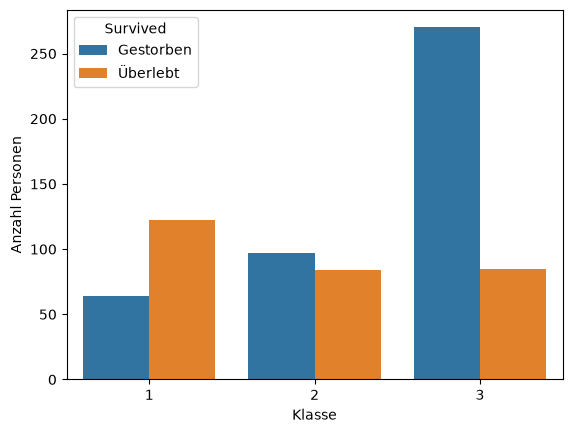

In [11]:
#Grouping Dataframe
df_copy = df.groupby(["Pclass", "Survived"], observed=False).size().reset_index(name="n")
df_copy["Survived"] = df_copy["Survived"].replace({
    0: "Gestorben",
    1: "Überlebt"
})
df_copy["Wahrscheinlichkeit"] = (
    df_copy["n"]
    / df_copy.groupby("Pclass")["n"].transform("sum")
    * 100
)

#Plotting 
sns.barplot(
    data=df_copy,
    x="Pclass",
    y="n",
    hue="Survived",
)

plt.xlabel("Klasse")
plt.ylabel("Anzahl Personen")
plt.show()

## Überlebende nach Altersgurppe 10 Jahre

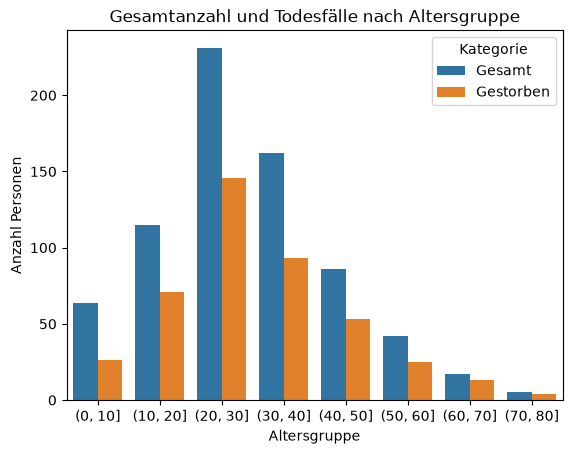

In [12]:
# Altersgruppen erstellen
df_age = df.dropna(subset=["Age"]).copy()

df_age["Age_group"] = pd.cut(
    df_age["Age"],
    bins=range(0, 90, 10)
)

# Gesamtanzahl Gäste pro Altersgruppe
total_by_age = (
    df_age.groupby("Age_group", observed=False)
    .size()
    .reset_index(name="Gesamt")
)

# Anzahl Gestorbene pro Altersgruppe
dead_by_age = (
    df_age[df_age["Survived"] == 0]
    .groupby("Age_group", observed=False)
    .size()
    .reset_index(name="Gestorben")
)

# Zusammenführen
age_stats = total_by_age.merge(
    dead_by_age,
    on="Age_group",
    how="left"
)

# Falls in einer Gruppe niemand gestorben ist
age_stats["Gestorben"] = age_stats["Gestorben"].fillna(0)

# Für Seaborn in lange Form bringen
age_plot = age_stats.melt(
    id_vars="Age_group",
    value_vars=["Gesamt", "Gestorben"],
    var_name="Kategorie",
    value_name="Anzahl"
)

age_plot["Age_group"] = age_plot["Age_group"].astype(str)

# Balkendiagramm
sns.barplot(
    data=age_plot,
    x="Age_group",
    y="Anzahl",
    hue="Kategorie"
)

plt.xlabel("Altersgruppe")
plt.ylabel("Anzahl Personen")
plt.title("Gesamtanzahl und Todesfälle nach Altersgruppe")

plt.show()

## Überlebende nach Geschlecht